# Panel & Temporal Analysis

**Goal:** Exploit the time dimension of the data to find temporal patterns — trend decomposition, change point detection, and panel regression with fixed effects.

**Key question:** Is Tunisia's BAC system improving over time? Are weaker regions catching up?

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

df_panel = pd.read_csv('../data/bac_panel.csv')
df_gov = pd.read_csv('../data/bac_crosssectional.csv')
YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
print('Data loaded.')

Data loaded.


In [ ]:
df_panel.columns

Index(['governorate', 'code', 'year', 'rank', 'success_rate', 'nb_lycees',
       'lycees_per_1k', 'poverty_rate', 'illiteracy_rate', 'population',
       'is_split_gov'],
      dtype='str')

In [ ]:
df_gov.columns

Index(['governorate', 'mean_rate', 'trend_slope', 'std_rate', 'min_rate',
       'max_rate', 'best_rank', 'worst_rank', 'covid_recovery_pct',
       'rank_volatility', 'nb_lycees', 'lycees_per_1k', 'poverty_rate',
       'illiteracy_rate', 'population', 'predicted_rate', 'residual',
       'outlier_type'],
      dtype='str')

## 1. Trend Analysis Per Governorate

We compute a linear trend (slope) for each governorate and classify them: improving, stable, or declining.

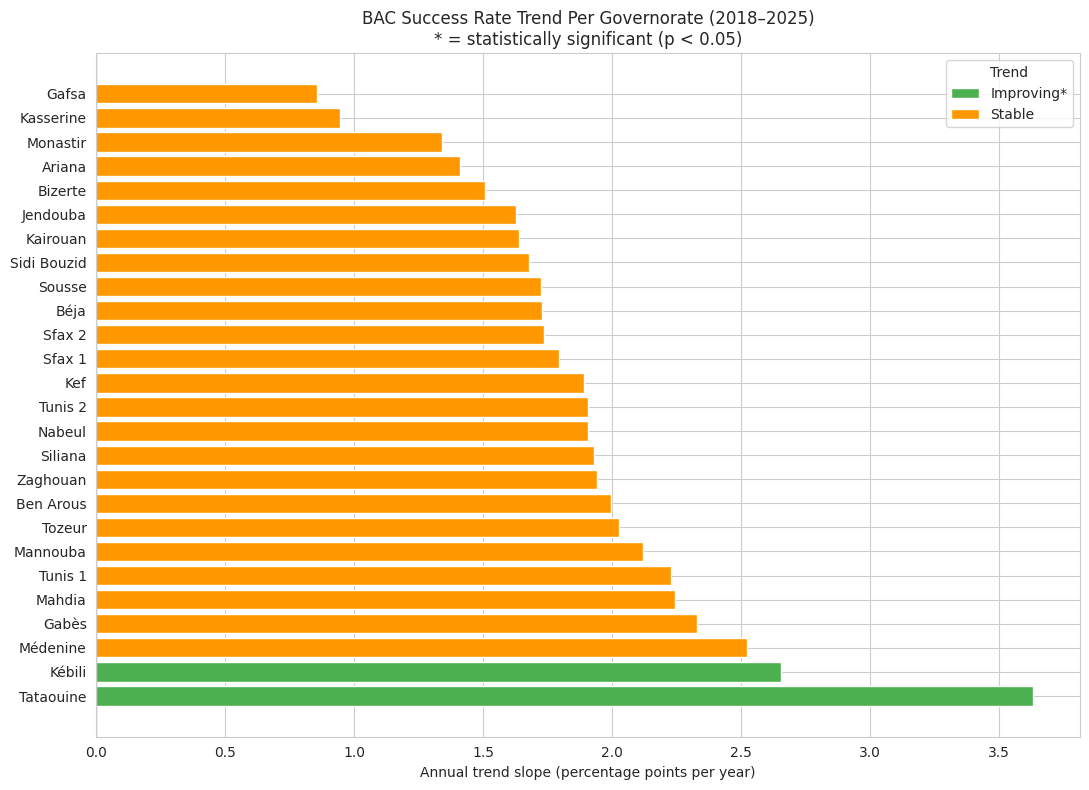

governorate  slope  p_value trend_label
  Tataouine 3.6339   0.0081  Improving*
     Kébili 2.6567   0.0164  Improving*
   Médenine 2.5239   0.0607      Stable
      Gabès 2.3295   0.1463      Stable
     Mahdia 2.2426   0.1585      Stable
    Tunis 1 2.2307   0.1250      Stable
   Mannouba 2.1206   0.1253      Stable
     Tozeur 2.0288   0.0776      Stable
  Ben Arous 1.9949   0.1299      Stable
   Zaghouan 1.9430   0.1213      Stable
    Siliana 1.9317   0.1145      Stable
     Nabeul 1.9073   0.1703      Stable
    Tunis 2 1.9054   0.2330      Stable
        Kef 1.8930   0.0700      Stable
     Sfax 1 1.7961   0.2548      Stable
     Sfax 2 1.7373   0.2087      Stable
       Béja 1.7293   0.1309      Stable
     Sousse 1.7246   0.2373      Stable
Sidi Bouzid 1.6768   0.0575      Stable
   Kairouan 1.6386   0.1236      Stable
   Jendouba 1.6290   0.0889      Stable
    Bizerte 1.5086   0.2539      Stable
     Ariana 1.4104   0.2338      Stable
   Monastir 1.3405   0.3782      Stable


In [ ]:
trend_results = []
for gov, group in df_panel.groupby('governorate'):
    group = group.sort_values('year')
    slope, intercept, r, p_value, se = stats.linregress(group['year'], group['success_rate'])
    trend_results.append({
        'governorate': gov,
        'slope': slope,
        'p_value': p_value,
        'r_squared': r**2,
        'significant': p_value < 0.05
    })

trend_df = pd.DataFrame(trend_results).sort_values('slope', ascending=False)
trend_df['trend_label'] = trend_df.apply(
    lambda r: 'Improving*' if r['significant'] and r['slope'] > 0
              else 'Declining*' if r['significant'] and r['slope'] < 0
              else 'Stable', axis=1
)

color_map = {'Improving*': '#4CAF50', 'Stable': '#FF9800', 'Declining*': '#F44336'}
fig, ax = plt.subplots(figsize=(11, 8))
for label, group in trend_df.groupby('trend_label'):
    ax.barh(group['governorate'], group['slope'],
            color=color_map[label], label=label, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Annual trend slope (percentage points per year)')
ax.set_title('BAC Success Rate Trend Per Governorate (2018–2025)\n* = statistically significant (p < 0.05)')
ax.legend(title='Trend')
plt.tight_layout()
plt.savefig('../outputs/visualisations/04_trend_per_governorate.png', dpi=150)
plt.show()

print(trend_df[['governorate', 'slope', 'p_value', 'trend_label']].round(4).to_string(index=False))

## 2. Change Point Detection

**Mining question:** Did a structural break occur in any governorate's trajectory — not just COVID (2020) but potentially a sustained shift? We use the PELT-inspired manual detection by looking at rate-of-change.

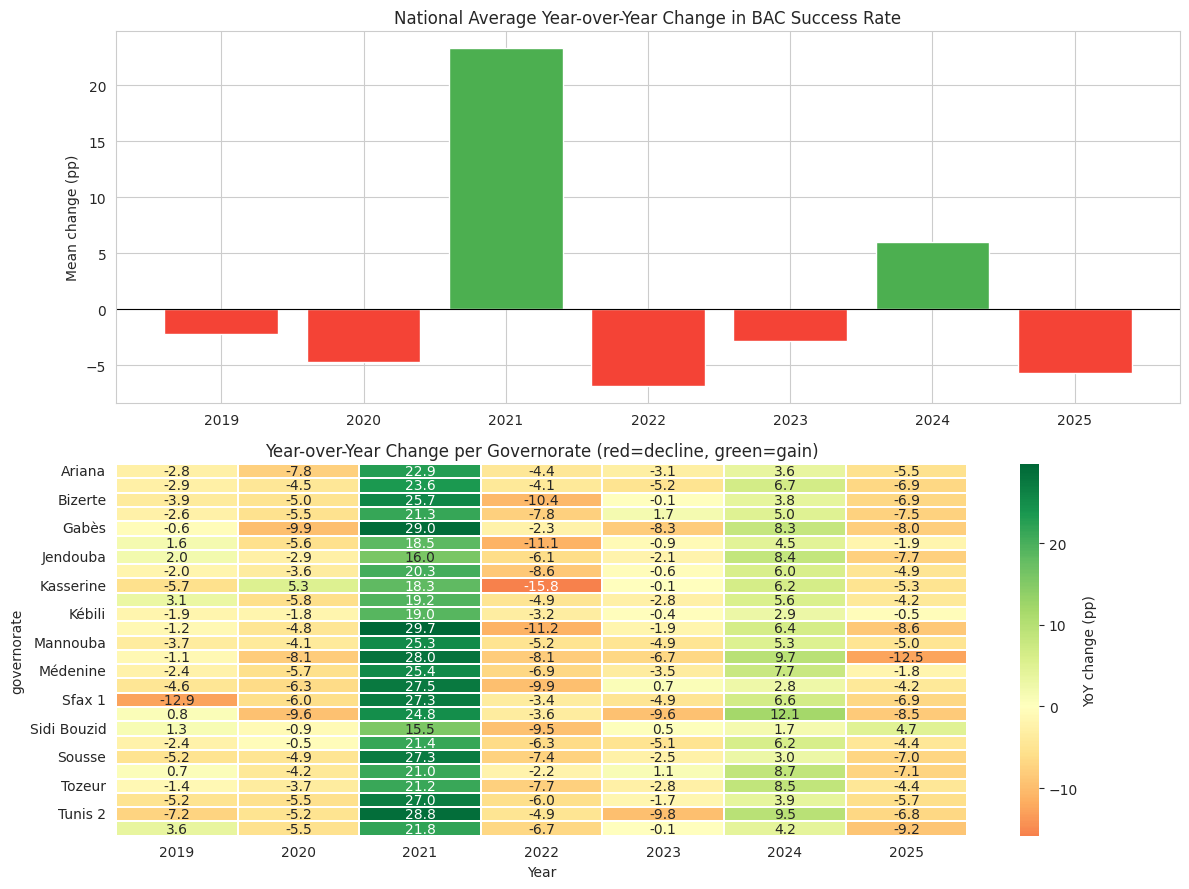

In [ ]:
# Compute year-over-year change per governorate
df_panel_sorted = df_panel.sort_values(['governorate', 'year'])
df_panel_sorted['yoy_change'] = df_panel_sorted.groupby('governorate')['success_rate'].diff()

# National average YoY change
national_yoy = df_panel_sorted.groupby('year')['yoy_change'].mean().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# Top: national YoY change
colors_bar = ['#4CAF50' if v > 0 else '#F44336' for v in national_yoy.values]
ax1.bar(national_yoy.index, national_yoy.values, color=colors_bar, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('National Average Year-over-Year Change in BAC Success Rate')
ax1.set_ylabel('Mean change (pp)')
ax1.set_xticks(national_yoy.index)

# Bottom: heatmap of YoY change per governorate
yoy_pivot = df_panel_sorted.pivot(index='governorate', columns='year', values='yoy_change').dropna(axis=1)
sns.heatmap(yoy_pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax2, cbar_kws={'label': 'YoY change (pp)'})
ax2.set_title('Year-over-Year Change per Governorate (red=decline, green=gain)')
ax2.set_xlabel('Year')

plt.tight_layout()
plt.savefig('../outputs/visualisations/04_change_points.png', dpi=150)
plt.show()

## 3. Convergence Analysis — Are Regions Catching Up?

**Mining question:** Beta-convergence test — do lower-performing governorates grow faster than higher-performing ones? This is a classic economic convergence test applied to education.

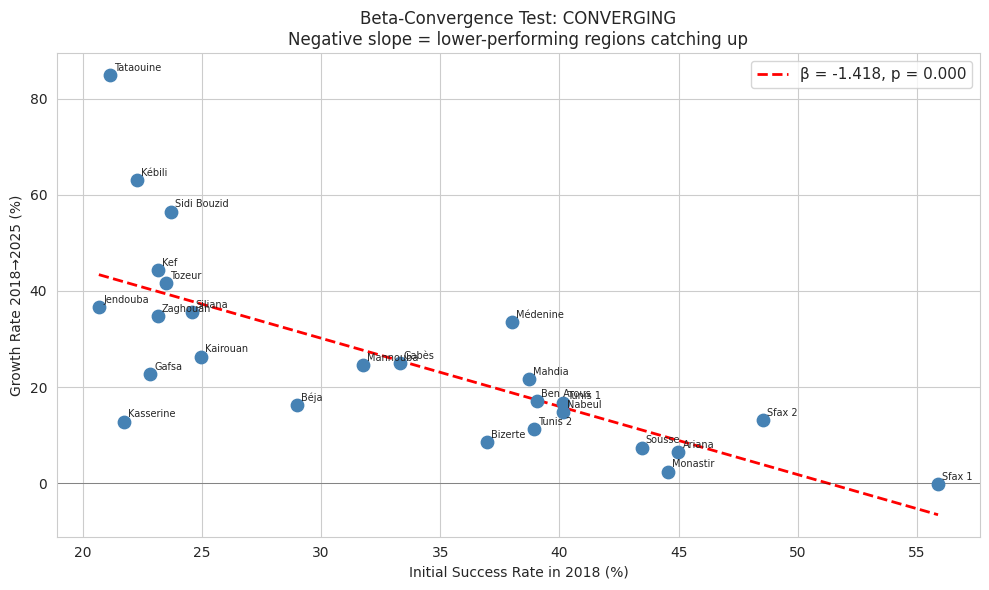

Slope: -1.4180 | p-value: 0.0000 | R²: 0.5187
Verdict: CONVERGING
The negative slope means weaker regions are growing faster — educational convergence is occurring.


In [ ]:
# Beta convergence: regress growth rate on initial level
# A negative slope = lower starters grow faster = convergence
rate_2018 = df_panel[df_panel['year'] == 2018].set_index('governorate')['success_rate']
rate_2025 = df_panel[df_panel['year'] == 2025].set_index('governorate')['success_rate']

common = rate_2018.index.intersection(rate_2025.index)
growth = ((rate_2025[common] - rate_2018[common]) / rate_2018[common] * 100)
initial = rate_2018[common]

slope, intercept, r, p, se = stats.linregress(initial.values, growth.values)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(initial, growth, s=80, color='steelblue', zorder=3)
for gov in common:
    ax.annotate(gov, (initial[gov], growth[gov]), fontsize=7, xytext=(3, 3), textcoords='offset points')

x_line = np.linspace(initial.min(), initial.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2,
        label=f'β = {slope:.3f}, p = {p:.3f}')
ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Initial Success Rate in 2018 (%)')
ax.set_ylabel('Growth Rate 2018→2025 (%)')
convergence_verdict = 'CONVERGING' if slope < 0 and p < 0.1 else 'NO CONVERGENCE'
ax.set_title(f'Beta-Convergence Test: {convergence_verdict}\n'
             f'Negative slope = lower-performing regions catching up')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/visualisations/04_convergence.png', dpi=150)
plt.show()

print(f'Slope: {slope:.4f} | p-value: {p:.4f} | R²: {r**2:.4f}')
print(f'Verdict: {convergence_verdict}')
if slope < 0:
    print('The negative slope means weaker regions are growing faster — educational convergence is occurring.')
else:
    print('The positive slope means stronger regions are growing faster — divergence, not convergence.')

## 4. Panel Fixed Effects Regression

By including year dummies, we control for national shocks (COVID, policy changes) and isolate the pure structural socioeconomic effect.

Panel R²: 0.8015

Coefficients:
        Feature  Coefficient
   poverty_rate    -0.518849
illiteracy_rate    -0.154361
  lycees_per_1k    -8.012832
      year_2019    -2.172308
      year_2020    -6.873077
      year_2021    16.428077
      year_2022     9.587308
      year_2023     6.783462
      year_2024    12.830385
      year_2025     7.177308


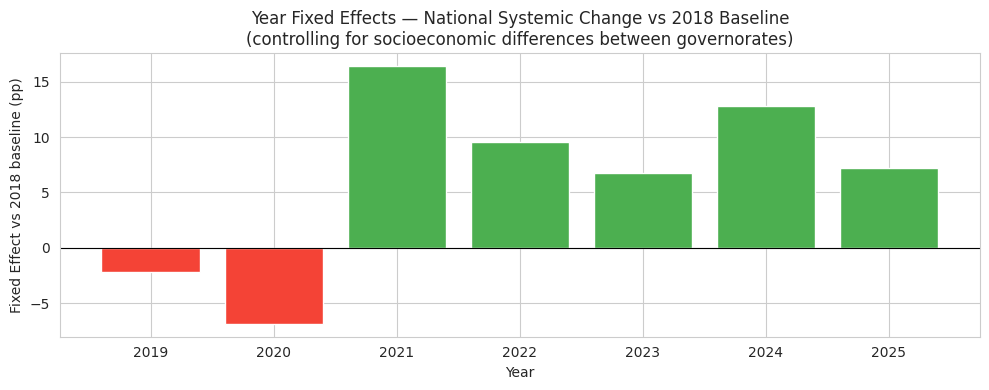

In [ ]:
# Merge socioeconomic features
# Drop duplicate columns from panel first to avoid _x/_y suffixes
df_panel_clean = df_panel.drop(
    columns=['poverty_rate', 'illiteracy_rate', 'population', 'lycees_per_1k'],
    errors='ignore'
)
socio_merge = df_gov[['governorate', 'poverty_rate', 'illiteracy_rate', 'lycees_per_1k']]
df_fe = df_panel_clean.merge(socio_merge, on='governorate', how='left')

# Create year dummies (excluding 2018 as reference)
year_dummies = pd.get_dummies(df_fe['year'], prefix='year', drop_first=True).astype(float)

X_fe = pd.concat([df_fe[['poverty_rate', 'illiteracy_rate', 'lycees_per_1k']], year_dummies], axis=1)
y_fe = df_fe['success_rate'].values

from sklearn.linear_model import LinearRegression
fe_model = LinearRegression()
fe_model.fit(X_fe, y_fe)

coef_df = pd.DataFrame({
    'Feature': X_fe.columns.tolist(),
    'Coefficient': fe_model.coef_
})

print(f'Panel R²: {fe_model.score(X_fe, y_fe):.4f}')
print('\nCoefficients:')
print(coef_df.to_string(index=False))

# Plot year coefficients to see national trend
year_coefs = coef_df[coef_df['Feature'].str.startswith('year_')].copy()
year_coefs['year'] = year_coefs['Feature'].str.replace('year_', '').astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(year_coefs['year'], year_coefs['Coefficient'],
       color=['#4CAF50' if v > 0 else '#F44336' for v in year_coefs['Coefficient']],
       edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Fixed Effect vs 2018 baseline (pp)')
ax.set_title('Year Fixed Effects — National Systemic Change vs 2018 Baseline\n'
             '(controlling for socioeconomic differences between governorates)')
plt.tight_layout()
plt.savefig('../outputs/visualisations/04_year_fixed_effects.png', dpi=150)
plt.show()

## 5. Spotlight — Most Interesting Trajectories

Manually highlight the governorates with the most surprising time series patterns.

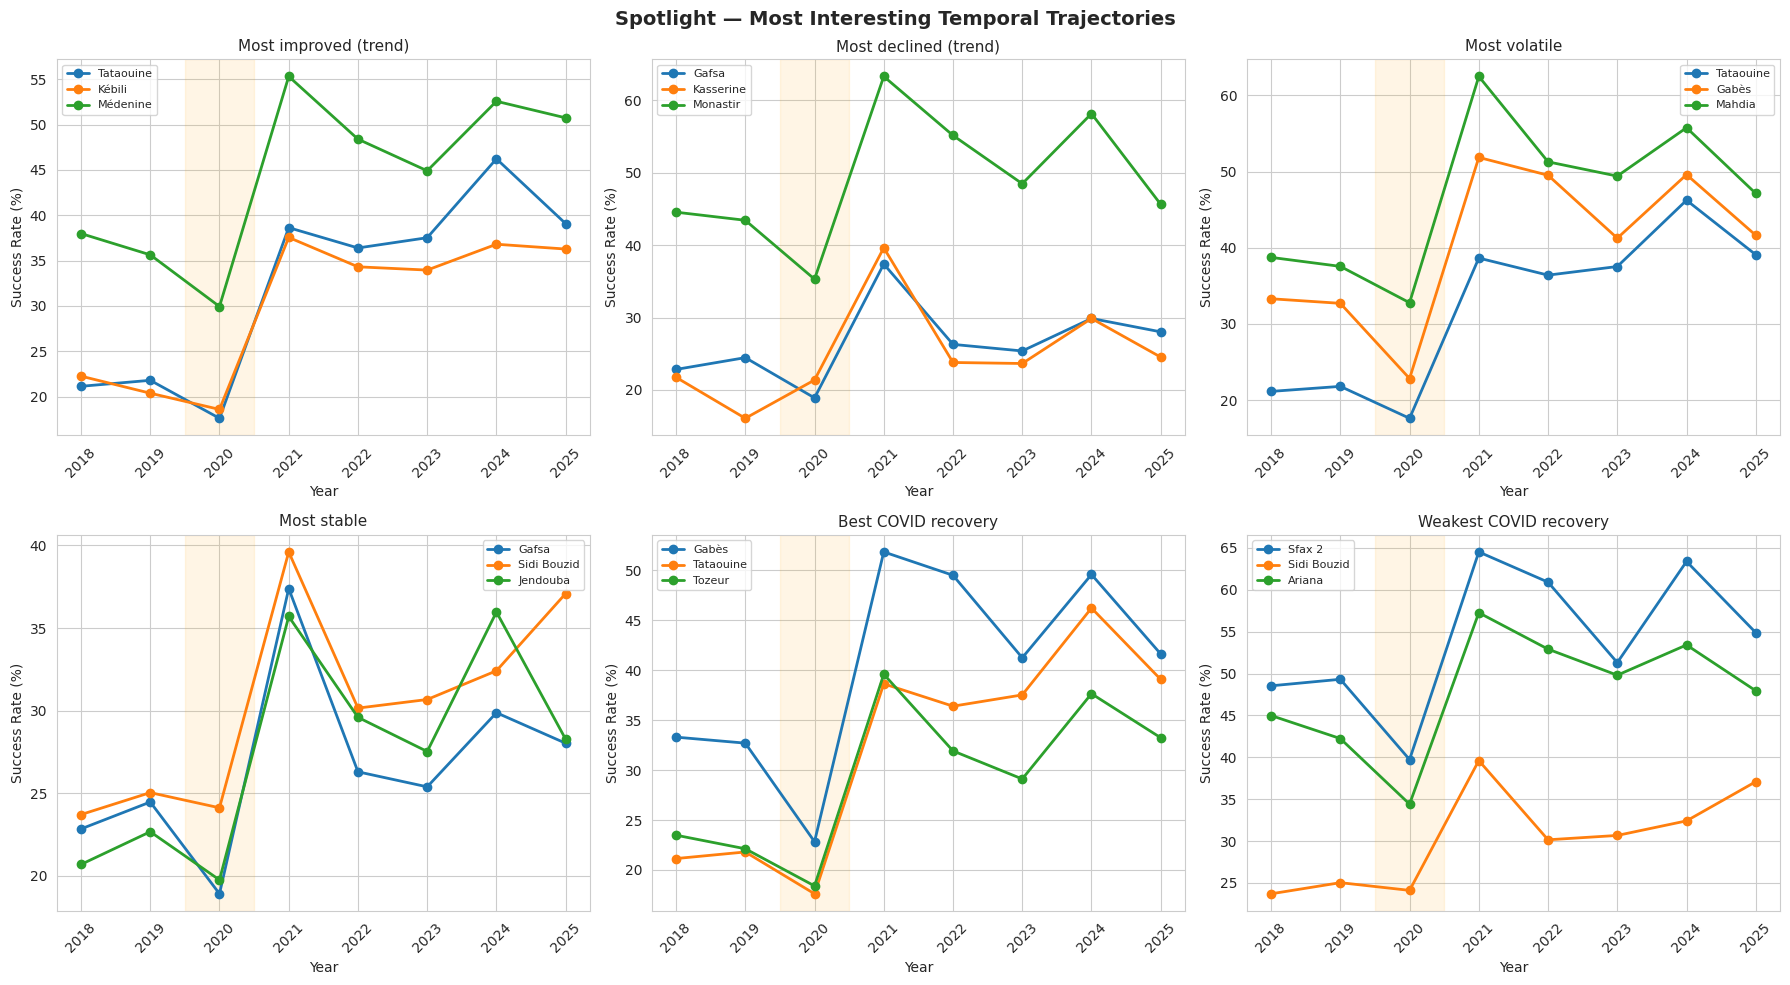

In [ ]:
# Most improved, most declined, most volatile, biggest COVID hit
spotlight = {
    'Most improved (trend)': df_gov.nlargest(3, 'trend_slope')['governorate'].tolist(),
    'Most declined (trend)': df_gov.nsmallest(3, 'trend_slope')['governorate'].tolist(),
    'Most volatile': df_gov.nlargest(3, 'std_rate')['governorate'].tolist(),
    'Most stable': df_gov.nsmallest(3, 'std_rate')['governorate'].tolist(),
    'Best COVID recovery': df_gov.nlargest(3, 'covid_recovery_pct')['governorate'].tolist(),
    'Weakest COVID recovery': df_gov.nsmallest(3, 'covid_recovery_pct')['governorate'].tolist(),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (title, govs) in zip(axes.flat, spotlight.items()):
    for gov in govs:
        data = df_panel[df_panel['governorate'] == gov].sort_values('year')
        ax.plot(data['year'], data['success_rate'], 'o-', linewidth=2, label=gov)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Success Rate (%)')
    ax.set_xticks(YEARS)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.axvspan(2019.5, 2020.5, color='orange', alpha=0.1)

plt.suptitle('Spotlight — Most Interesting Temporal Trajectories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/visualisations/04_spotlight_trajectories.png', dpi=150)
plt.show()